# Deterministic-average circuit QPINN with `torch.autograd`

This notebook is the simpler simulation counterpart of `QPINN_hyperoctahedral_chebyshev.ipynb`.  It keeps the same quantum-circuit QFM and the same screened Poisson problem, but it computes the average operator exactly and uses `torch.autograd` for the PDE residual.

The PDE is

$$
(-\Delta+\lambda)u(x)=q(x), \qquad x=(x_1,x_2)\in[-1,1]^2,
$$

with homogeneous Dirichlet boundary condition $u|_{\partial\Omega}=0$.  Let

$$
\phi_m(t)=\cos\left(\frac{m\pi t}{2}\right).
$$

The source is

$$
q(x_1,x_2)=
\phi_1(x_1)\phi_1(x_2)
+0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right],
$$

with analytical solution

$$
u_\star(x_1,x_2)=
\frac{\phi_1(x_1)\phi_1(x_2)}{\lambda+\pi^2/2}
+\frac{0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right]}{\lambda+5\pi^2/2}.
$$

We compare three circuit models:

$$
f_\theta(x),
\qquad
f_\theta(\arccos x),
\qquad
(A_{B_2}f_\theta)(\arccos x).
$$

The middle model is the Kyriienko-style Chebyshev feature map: it simply feeds $u=\arccos x$ into the QFM.  As discussed around Eq. 36 of the manuscript, this direct substitution produces Chebyshev-like terms but does not by itself remove all non-polynomial components.  The last model restores the earlier working exact average operator over sign flips and coordinate permutations of the physical input $x$.

This exact-average/autograd version is not the resource-efficient hardware estimator.  Its purpose is to test the modeling effect before adding randomized encoding and parameter-shift sampling.

In [90]:
from __future__ import annotations

from collections import defaultdict
from copy import deepcopy
from itertools import permutations, product
from pathlib import Path
import os
import sys
import tempfile

import numpy as np
import torch

_MPL_CACHE = Path(tempfile.gettempdir()) / "matplotlib-cache"
_MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_CACHE))
_XDG_CACHE = Path(tempfile.gettempdir()) / "xdg-cache"
_XDG_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(_XDG_CACHE))

IS_NOTEBOOK = "ipykernel" in sys.modules
import matplotlib
if not IS_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_or_close_current_figure() -> None:
    if IS_NOTEBOOK:
        plt.show()
    else:
        plt.close()


USE_DOUBLE_PRECISION = False


def _candidate_dtypes(candidate: torch.device):
    if USE_DOUBLE_PRECISION and candidate.type != "mps":
        return torch.float64, torch.complex128
    return torch.float32, torch.complex64


def _complex_autograd_works(candidate: torch.device) -> bool:
    real_dt, complex_dt = _candidate_dtypes(candidate)
    try:
        theta = torch.tensor(0.37, dtype=real_dt, device=candidate, requires_grad=True)
        half = 0.5 * theta
        c = torch.cos(half)
        s = torch.sin(half)
        gate = torch.stack(
            [
                torch.stack([torch.complex(c, torch.zeros_like(c)), torch.complex(torch.zeros_like(s), -s)]),
                torch.stack([torch.complex(torch.zeros_like(s), -s), torch.complex(c, torch.zeros_like(c))]),
            ]
        ).to(complex_dt)
        loss = (gate.abs() ** 2).sum()
        loss.backward()
        return theta.grad is not None and torch.isfinite(theta.grad)
    except Exception as exc:
        print(f"Skipping {candidate.type}: complex autograd check failed ({exc}).")
        return False


def select_accelerated_device() -> torch.device:
    candidates = []
    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))
    candidates.append(torch.device("cpu"))

    for candidate in candidates:
        if _complex_autograd_works(candidate):
            return candidate
    return torch.device("cpu")


DEVICE = select_accelerated_device()
REAL_DTYPE, COMPLEX_DTYPE = _candidate_dtypes(DEVICE)
torch.set_default_dtype(REAL_DTYPE)

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)


def locate_paper_work_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "MSQE").exists() and cwd.name == "Paper_work":
        return cwd
    if (cwd / "Paper_work" / "MSQE").exists():
        return cwd / "Paper_work"
    for parent in cwd.parents:
        if (parent / "Paper_work" / "MSQE").exists():
            return parent / "Paper_work"
    return cwd


PAPER_WORK_DIR = locate_paper_work_dir()
FIGURE_DIR = PAPER_WORK_DIR / "MSQE" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device={DEVICE}, real dtype={REAL_DTYPE}, complex dtype={COMPLEX_DTYPE}")

Skipping mps: complex autograd check failed (The operator 'aten::complex.out' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.).
Using device=cpu, real dtype=torch.float32, complex dtype=torch.complex64


## Circuit QFM ansatz

The baseline circuit is a data re-uploading QFM.  Each upload block applies a trainable StronglyEntanglingLayer-style block followed by exponential Pauli encoding,

$$
R_X(\beta_j z_j)=\exp[-i\beta_jz_jX_j/2],
\qquad \beta_j=3^j .
$$

The circuit input $z$ is the physical coordinate $x$ for the Ordinary QFM and the $B_2$-symmetrized model, while the Cheb-QFM baseline uses the Chebyshev angle $u=\arccos x$.  The $B_2$-QCM restores the earlier working exact average over sign flips and coordinate permutations of the physical PDE input.

For GPU use, the exact group average is evaluated as one batched circuit call.  Instead of looping over group elements in Python, the transformed inputs are stacked into a tensor of shape `group_size * batch`, passed through `base_circuit` once, and then averaged after reshaping.  This does not change the mathematical model, but it avoids many small CUDA kernels.

In [91]:
DIM = 2
N_QUBITS = 2
N_UPLOAD_LAYERS = 2
STRONG_LAYERS_PER_BLOCK = 1

EXP_BASE = 3.0
ENCODING_SCALE = 1.0
DIFF_GENERATOR_PER_LAYER = False
ACOS_EPS = 1.0e-6

LAMBDA = 1.0
SOURCE_MODE_COEFFICIENTS = {
    (1, 1): 1.0,
    (1, 3): 0.3,
    (3, 1): 0.3,
}

TRAINING_STEPS = 100
N_RUNS = 5
INTERIOR_BATCH = 16
BOUNDARY_BATCH = 16
LR = 1e-2
BOUNDARY_WEIGHT = 10.0
INTERIOR_MARGIN = 0.94
GRAD_CLIP = 5.0

EVAL_GRID_N = 41

assert DIM == 2, "This benchmark cell is written for the B_2 screened-Poisson example."
assert N_QUBITS >= DIM, "The circuit uses one encoding wire per input coordinate."


In [92]:
_CNOT_GATHER_CACHE: dict[tuple[int, int, int, str], torch.Tensor] = {}


def as_1d(theta: torch.Tensor) -> torch.Tensor:
    return theta.reshape(1) if theta.ndim == 0 else theta


def complex_pair(real: torch.Tensor, imag: torch.Tensor) -> torch.Tensor:
    return torch.complex(real, imag).to(COMPLEX_DTYPE)


def rx_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    row0 = torch.stack([complex_pair(c, z), complex_pair(z, -s)], dim=-1)
    row1 = torch.stack([complex_pair(z, -s), complex_pair(c, z)], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def ry_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    row0 = torch.stack([complex_pair(c, torch.zeros_like(c)), complex_pair(-s, torch.zeros_like(s))], dim=-1)
    row1 = torch.stack([complex_pair(s, torch.zeros_like(s)), complex_pair(c, torch.zeros_like(c))], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def rz_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    row0 = torch.stack([complex_pair(c, -s), complex_pair(z, z)], dim=-1)
    row1 = torch.stack([complex_pair(z, z), complex_pair(c, s)], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def rot_matrix(phi: torch.Tensor, theta: torch.Tensor, omega: torch.Tensor) -> torch.Tensor:
    return rz_matrix(omega) @ ry_matrix(theta) @ rz_matrix(phi)


def apply_single_qubit_gate(state: torch.Tensor, gate: torch.Tensor, wire: int) -> torch.Tensor:
    batch = state.shape[0]
    if gate.shape[0] == 1 and batch != 1:
        gate = gate.expand(batch, -1, -1)
    tensor = state.reshape(batch, *([2] * N_QUBITS))
    axis = wire + 1
    tensor = tensor.movedim(axis, -1)
    updated = torch.einsum("bij,b...j->b...i", gate, tensor)
    updated = updated.movedim(-1, axis)
    return updated.reshape(batch, 2**N_QUBITS)


def cnot_gather_index(n_qubits: int, control: int, target: int, device: torch.device) -> torch.Tensor:
    key = (n_qubits, control, target, device.type)
    if key in _CNOT_GATHER_CACHE:
        return _CNOT_GATHER_CACHE[key]

    gather = [0] * (2**n_qubits)
    for input_index in range(2**n_qubits):
        bits = [(input_index >> (n_qubits - 1 - q)) & 1 for q in range(n_qubits)]
        output_bits = bits[:]
        if bits[control] == 1:
            output_bits[target] ^= 1
        output_index = 0
        for bit in output_bits:
            output_index = (output_index << 1) | bit
        gather[output_index] = input_index

    tensor = torch.tensor(gather, dtype=torch.long, device=device)
    _CNOT_GATHER_CACHE[key] = tensor
    return tensor


def apply_cnot(state: torch.Tensor, control: int, target: int) -> torch.Tensor:
    gather = cnot_gather_index(N_QUBITS, control, target, state.device)
    return state[:, gather]


def apply_strongly_entangling_block(state: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    for sublayer in range(weights.shape[0]):
        for wire in range(N_QUBITS):
            phi, theta, omega = weights[sublayer, wire]
            state = apply_single_qubit_gate(state, rot_matrix(phi, theta, omega), wire)

        if N_QUBITS > 1:
            cnot_range = (sublayer % (N_QUBITS - 1)) + 1
            for control in range(N_QUBITS):
                target = (control + cnot_range) % N_QUBITS
                state = apply_cnot(state, control, target)
    return state


def initial_state(batch: int) -> torch.Tensor:
    state = torch.zeros(batch, 2**N_QUBITS, dtype=COMPLEX_DTYPE, device=DEVICE)
    state[:, 0] = torch.ones(batch, dtype=COMPLEX_DTYPE, device=DEVICE)
    return state


def z_feature_values() -> torch.Tensor:
    values = []
    for basis_index in range(2**N_QUBITS):
        bits = [(basis_index >> (N_QUBITS - 1 - q)) & 1 for q in range(N_QUBITS)]
        z0 = 1.0 if bits[0] == 0 else -1.0
        z1 = 1.0 if bits[1] == 0 else -1.0
        values.append([z0, z1, z0 * z1])
    return torch.tensor(values, dtype=REAL_DTYPE, device=DEVICE)


Z_FEATURE_VALUES = z_feature_values()

In [93]:
SIGNFLIP_SIGNS = torch.tensor(list(product([-1.0, 1.0], repeat=DIM)), dtype=REAL_DTYPE, device=DEVICE)
B2_PERMUTATIONS = torch.tensor(list(permutations(range(DIM))), dtype=torch.long, device=DEVICE)


def map_circuit_input(x: torch.Tensor, input_map: str) -> torch.Tensor:
    if input_map == "raw":
        return x
    if input_map == "chebyshev":
        return torch.acos(torch.clamp(x, -1.0 + ACOS_EPS, 1.0 - ACOS_EPS))
    raise ValueError(f"Unknown input_map: {input_map}")


def group_transformed_batch(z: torch.Tensor, group: str) -> tuple[torch.Tensor, int]:
    if group == "none":
        return z, 1

    if group == "hyperoctahedral":
        permuted = z[:, B2_PERMUTATIONS].permute(1, 0, 2)
        transformed = permuted[:, None, :, :] * SIGNFLIP_SIGNS[None, :, None, :]
        group_size = B2_PERMUTATIONS.shape[0] * SIGNFLIP_SIGNS.shape[0]
        return transformed.reshape(-1, DIM), group_size

    raise ValueError(f"Unknown group: {group}")


class ReuploadingStrongEntangleQFM(torch.nn.Module):
    def __init__(self, group: str, input_map: str, init_scale: float = 0.2):
        super().__init__()
        self.group = group
        self.input_map = input_map
        weight_shape = (N_UPLOAD_LAYERS + 1, STRONG_LAYERS_PER_BLOCK, N_QUBITS, 3)
        self.weights = torch.nn.Parameter(
            init_scale * torch.randn(weight_shape, dtype=REAL_DTYPE, device=DEVICE)
        )
        self.readout_weights = torch.nn.Parameter(
            torch.tensor([0.5, 0.5, 0.1], dtype=REAL_DTYPE, device=DEVICE)
        )
        self.readout_bias = torch.nn.Parameter(torch.zeros((), dtype=REAL_DTYPE, device=DEVICE))
        self.output_scale = torch.nn.Parameter(torch.tensor(0.5, dtype=REAL_DTYPE, device=DEVICE))

    @staticmethod
    def encoding_beta(upload: int, wire: int) -> float:
        exponent = upload * N_QUBITS + wire if DIFF_GENERATOR_PER_LAYER else wire
        return EXP_BASE ** exponent

    def base_circuit(self, z: torch.Tensor) -> torch.Tensor:
        batch = z.shape[0]
        state = initial_state(batch)

        for upload in range(N_UPLOAD_LAYERS):
            state = apply_strongly_entangling_block(state, self.weights[upload])
            for wire in range(N_QUBITS):
                coordinate = wire % DIM
                beta = self.encoding_beta(upload, wire)
                angle = ENCODING_SCALE * beta * z[:, coordinate]
                state = apply_single_qubit_gate(state, rx_matrix(angle), wire)

        state = apply_strongly_entangling_block(state, self.weights[-1])
        probabilities = (state.abs() ** 2).real
        pauli_features = probabilities @ Z_FEATURE_VALUES
        expectation_readout = pauli_features @ self.readout_weights
        return self.readout_bias + self.output_scale * expectation_readout

    def forward_from_circuit_input(self, z: torch.Tensor) -> torch.Tensor:
        transformed_z, group_size = group_transformed_batch(z, self.group)
        transformed_outputs = self.base_circuit(transformed_z)
        return transformed_outputs.reshape(group_size, z.shape[0]).mean(dim=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = map_circuit_input(x, self.input_map)
        return self.forward_from_circuit_input(z)


MODEL_SPECS = {
    "Ordinary QFM": {"group": "none", "input_map": "raw"},
    "Cheb-QFM": {"group": "none", "input_map": "chebyshev"},
    "$B_2$-QCM": {"group": "hyperoctahedral", "input_map": "raw"},
}


def make_models(seed: int = SEED) -> dict[str, ReuploadingStrongEntangleQFM]:
    torch.manual_seed(seed)
    reference = ReuploadingStrongEntangleQFM(group="none", input_map="raw")
    reference_state = deepcopy(reference.state_dict())

    models = {}
    for name, spec in MODEL_SPECS.items():
        model = ReuploadingStrongEntangleQFM(**spec)
        model.load_state_dict(reference_state)
        models[name] = model
    return models

## Autograd QPINN loss

The empirical loss is

$$
\mathcal L(\theta)=
\frac{1}{N_\Omega}\sum_i
\left[(-\Delta+\lambda)u_\theta(x_i)-q(x_i)\right]^2
+\mu\frac{1}{N_{\partial\Omega}}\sum_i u_\theta(y_i)^2.
$$

Here the Laplacian is computed by differentiating the circuit output with respect to the physical input coordinates using `torch.autograd`.

In [94]:
def phi_mode(x: torch.Tensor, mode: int) -> torch.Tensor:
    return torch.cos(0.5 * mode * torch.pi * x)


def source_term(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2)
    return value


def analytical_solution(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        eigenvalue = (0.5 * torch.pi * m1) ** 2 + (0.5 * torch.pi * m2) ** 2
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2) / (LAMBDA + eigenvalue)
    return value


def laplacian(model: torch.nn.Module, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    u = model(x_req)
    grad_u = torch.autograd.grad(u.sum(), x_req, create_graph=True)[0]

    lap = torch.zeros_like(u)
    for dim in range(DIM):
        second = torch.autograd.grad(grad_u[:, dim].sum(), x_req, create_graph=True)[0][:, dim]
        lap = lap + second
    return lap, u


def physics_loss(model: torch.nn.Module, interior_x: torch.Tensor, boundary_x: torch.Tensor) -> tuple[torch.Tensor, dict[str, float]]:
    lap, u_interior = laplacian(model, interior_x)
    residual = -lap + LAMBDA * u_interior - source_term(interior_x)
    residual_loss = torch.mean(residual**2)

    u_boundary = model(boundary_x)
    boundary_loss = torch.mean(u_boundary**2)
    loss = residual_loss + BOUNDARY_WEIGHT * boundary_loss

    metrics = {
        "loss": float(loss.detach().cpu()),
        "residual": float(residual_loss.detach().cpu()),
        "boundary": float(boundary_loss.detach().cpu()),
    }
    return loss, metrics

In [95]:
def sample_interior(batch: int) -> torch.Tensor:
    return (2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0) * INTERIOR_MARGIN


def sample_boundary(batch: int) -> torch.Tensor:
    x = 2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0
    sides = torch.randint(0, 2 * DIM, (batch,), device=DEVICE)
    for dim in range(DIM):
        left = sides == 2 * dim
        right = sides == 2 * dim + 1
        x[left, dim] = -1.0
        x[right, dim] = 1.0
    return x


def make_training_batches(seed: int) -> list[tuple[torch.Tensor, torch.Tensor]]:
    torch.manual_seed(seed)
    return [
        (sample_interior(INTERIOR_BATCH), sample_boundary(BOUNDARY_BATCH))
        for _ in range(TRAINING_STEPS)
    ]


def train_model(
    name: str,
    model: torch.nn.Module,
    training_batches: list[tuple[torch.Tensor, torch.Tensor]],
    run_index: int,
) -> dict[str, list[float]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = defaultdict(list)

    for step, (interior_x, boundary_x) in enumerate(training_batches, start=1):
        optimizer.zero_grad(set_to_none=True)
        loss, metrics = physics_loss(model, interior_x, boundary_x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        for key, value in metrics.items():
            history[key].append(value)

        if run_index == 0 and (step == 1 or step % max(1, TRAINING_STEPS // 5) == 0):
            print(
                f"{name:24s} run {run_index + 1:2d}/{N_RUNS}, step {step:4d}/{TRAINING_STEPS}: "
                f"loss={metrics['loss']:.3e}, residual={metrics['residual']:.3e}, boundary={metrics['boundary']:.3e}"
            )

    return dict(history)


def evaluation_grid(n: int = EVAL_GRID_N) -> tuple[torch.Tensor, np.ndarray, np.ndarray]:
    axis = torch.linspace(-1.0, 1.0, n, dtype=REAL_DTYPE, device=DEVICE)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack([x1.reshape(-1), x2.reshape(-1)], dim=1)
    return points, x1.detach().cpu().numpy(), x2.detach().cpu().numpy()


@torch.no_grad()
def evaluate_model(model: torch.nn.Module, points: torch.Tensor) -> torch.Tensor:
    return model(points).detach()


def relative_l2_error(pred: torch.Tensor, target: torch.Tensor) -> float:
    return float(torch.linalg.norm(pred - target).cpu() / torch.linalg.norm(target).cpu())


def symmetry_defects(model: torch.nn.Module, points: torch.Tensor) -> dict[str, float]:
    with torch.no_grad():
        base = model(points)

        z = map_circuit_input(points, model.input_map)
        model_input_sign_flip = model.forward_from_circuit_input(
            z * torch.tensor([-1.0, 1.0], dtype=REAL_DTYPE, device=DEVICE)
        )

        permutation = model(points[:, [1, 0]])
        physical_sign_flip = model(points * torch.tensor([-1.0, 1.0], dtype=REAL_DTYPE, device=DEVICE))

    return {
        "model_input_sign_flip_mse": float(torch.mean((base - model_input_sign_flip) ** 2).cpu()),
        "permutation_mse": float(torch.mean((base - permutation) ** 2).cpu()),
        "physical_evenness_mse": float(torch.mean((base - physical_sign_flip) ** 2).cpu()),
    }

In [96]:
all_histories = {model_name: [] for model_name in MODEL_SPECS}
all_models_by_run = []
final_losses = {model_name: [] for model_name in MODEL_SPECS}

for run_index in range(N_RUNS):
    init_seed = SEED + 1000 * run_index
    batch_seed = SEED + 1000 * run_index + 137
    print(f"\n=== Run {run_index + 1}/{N_RUNS} | init_seed={init_seed}, batch_seed={batch_seed} ===")

    models = make_models(seed=init_seed)
    training_batches = make_training_batches(seed=batch_seed)

    run_histories = {}
    for model_name, model in models.items():
        print(f"Training {model_name}")
        history = train_model(model_name, model, training_batches, run_index)
        all_histories[model_name].append(history)
        final_losses[model_name].append(history["loss"][-1])
        run_histories[model_name] = history

    all_models_by_run.append(models)


def stack_loss_histories(metric: str = "loss") -> dict[str, np.ndarray]:
    return {
        model_name: np.asarray([history[metric] for history in histories], dtype=float)
        for model_name, histories in all_histories.items()
    }


loss_runs = stack_loss_histories("loss")
loss_floor = 1.0e-300
loss_log_runs = {
    model_name: np.log(np.clip(values, loss_floor, None))
    for model_name, values in loss_runs.items()
}

loss_log_mean = {model_name: values.mean(axis=0) for model_name, values in loss_log_runs.items()}
loss_log_variance = {
    model_name: values.var(axis=0, ddof=1) if values.shape[0] > 1 else np.zeros(values.shape[1])
    for model_name, values in loss_log_runs.items()
}
loss_log_std = {model_name: np.sqrt(values) for model_name, values in loss_log_variance.items()}

loss_geo_mean = {model_name: np.exp(values) for model_name, values in loss_log_mean.items()}
loss_geo_lower = {
    model_name: np.exp(loss_log_mean[model_name] - loss_log_std[model_name])
    for model_name in loss_runs
}
loss_geo_upper = {
    model_name: np.exp(loss_log_mean[model_name] + loss_log_std[model_name])
    for model_name in loss_runs
}
loss_geo_std_factor = {model_name: np.exp(values) for model_name, values in loss_log_std.items()}

representative_run_index = {
    model_name: int(np.argmin(losses))
    for model_name, losses in final_losses.items()
}

models = {
    model_name: all_models_by_run[run_index][model_name]
    for model_name, run_index in representative_run_index.items()
}

histories = {
    model_name: all_histories[model_name][run_index]
    for model_name, run_index in representative_run_index.items()
}

print("\nRepresentative runs selected by lowest final training loss:")
for model_name, run_index in representative_run_index.items():
    print(f"  {model_name:24s}: run {run_index + 1}/{N_RUNS}, final loss={final_losses[model_name][run_index]:.3e}")


=== Run 1/5 | init_seed=7, batch_seed=144 ===
Training Ordinary QFM
Ordinary QFM             run  1/5, step    1/100: loss=1.513e+01, residual=1.509e+01, boundary=3.831e-03
Ordinary QFM             run  1/5, step   20/100: loss=7.884e-01, residual=7.584e-01, boundary=2.996e-03
Ordinary QFM             run  1/5, step   40/100: loss=3.457e-01, residual=3.289e-01, boundary=1.678e-03
Ordinary QFM             run  1/5, step   60/100: loss=1.492e-01, residual=1.389e-01, boundary=1.038e-03
Ordinary QFM             run  1/5, step   80/100: loss=2.132e-01, residual=1.928e-01, boundary=2.044e-03
Ordinary QFM             run  1/5, step  100/100: loss=1.089e-01, residual=1.010e-01, boundary=7.840e-04
Training Cheb-QFM
Cheb-QFM                 run  1/5, step    1/100: loss=5.238e+01, residual=5.223e+01, boundary=1.505e-02
Cheb-QFM                 run  1/5, step   20/100: loss=1.175e+00, residual=1.133e+00, boundary=4.223e-03
Cheb-QFM                 run  1/5, step   40/100: loss=4.050e-01, residua

In [97]:
grid_points, grid_x1, grid_x2 = evaluation_grid()
target = analytical_solution(grid_points).detach()
target_grid = target.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)

predictions = {}
prediction_stats = {}
errors = {}
symmetry = {}

for model_name, model in models.items():
    pred = evaluate_model(model, grid_points)
    pred_grid = pred.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)
    predictions[model_name] = pred_grid
    prediction_stats[model_name] = {
        "min": float(pred.min().cpu()),
        "max": float(pred.max().cpu()),
        "mean": float(pred.mean().cpu()),
        "std": float(pred.std().cpu()),
    }
    errors[model_name] = relative_l2_error(pred, target)
    symmetry[model_name] = symmetry_defects(model, grid_points)

target_stats = {
    "min": float(target.min().cpu()),
    "max": float(target.max().cpu()),
    "mean": float(target.mean().cpu()),
    "std": float(target.std().cpu()),
}

print("Target range")
print(f"  analytical solution     : min={target_stats['min']:.3e}, max={target_stats['max']:.3e}, std={target_stats['std']:.3e}")

print("\nPrediction ranges and relative L2 errors")
for model_name, error in errors.items():
    stats = prediction_stats[model_name]
    print(
        f"  {model_name:24s}: rel-L2={error:.4e}, "
        f"min={stats['min']:.3e}, max={stats['max']:.3e}, std={stats['std']:.3e}"
    )

print("\nSymmetry diagnostics")
for model_name, defects in symmetry.items():
    print(
        f"  {model_name:24s}: model-input sign-flip MSE={defects['model_input_sign_flip_mse']:.3e}, "
        f"permutation MSE={defects['permutation_mse']:.3e}, "
        f"physical x sign-flip MSE={defects['physical_evenness_mse']:.3e}"
    )

Target range
  analytical solution     : min=-7.737e-09, max=1.919e-01, std=5.464e-02

Prediction ranges and relative L2 errors
  Ordinary QFM            : rel-L2=3.8278e-01, min=-2.510e-03, max=1.419e-01, std=3.942e-02
  Cheb-QFM                : rel-L2=6.6986e-01, min=2.833e-02, max=5.826e-02, std=6.204e-03
  $B_2$-QCM               : rel-L2=8.8066e-02, min=-4.252e-03, max=1.877e-01, std=4.991e-02

Symmetry diagnostics
  Ordinary QFM            : model-input sign-flip MSE=2.566e-04, permutation MSE=1.868e-03, physical x sign-flip MSE=2.566e-04
  Cheb-QFM                : model-input sign-flip MSE=7.595e-05, permutation MSE=7.812e-05, physical x sign-flip MSE=5.362e-05
  $B_2$-QCM               : model-input sign-flip MSE=2.355e-17, permutation MSE=2.902e-17, physical x sign-flip MSE=2.355e-17


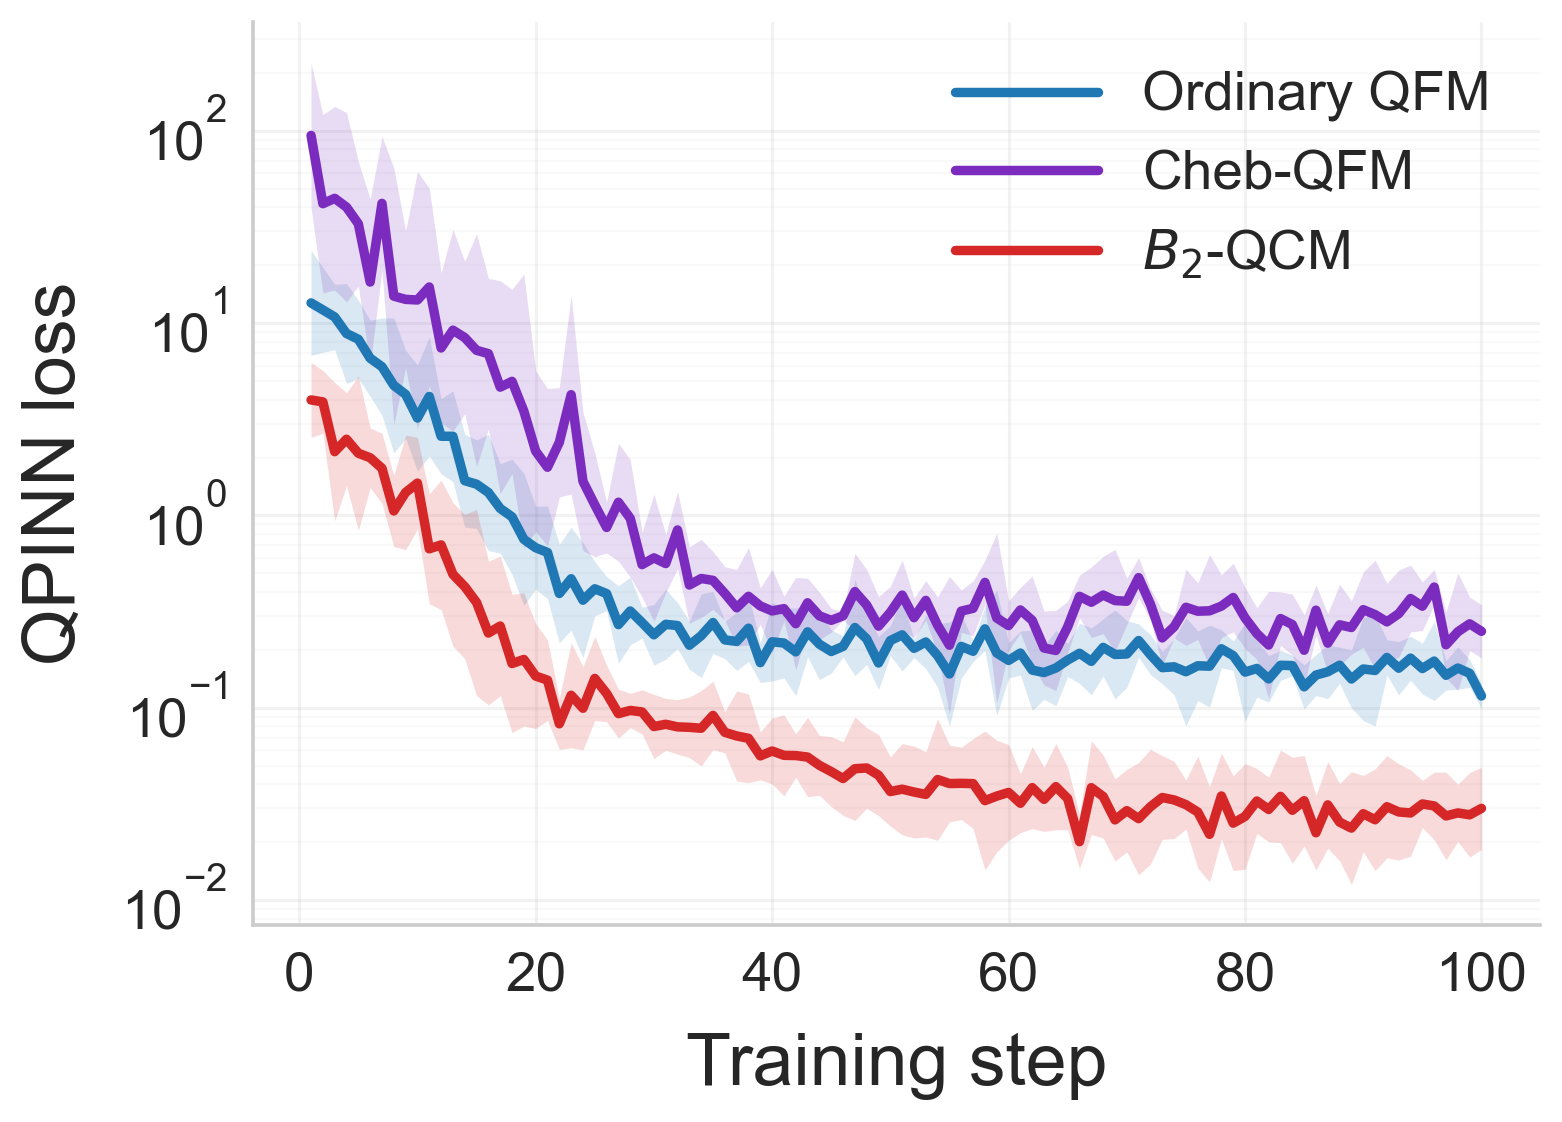

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_training_loss.png


In [98]:
LOSS_COLORS = {
    "Ordinary QFM": "#1f77b4",
    "Cheb-QFM": "#7b2cbf",
    "$B_2$-QCM": "#d62728",
}

steps = np.arange(1, TRAINING_STEPS + 1)
fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=220)

for model_name in MODEL_SPECS:
    mean = loss_geo_mean[model_name]
    lower = loss_geo_lower[model_name]
    upper = loss_geo_upper[model_name]
    color = LOSS_COLORS[model_name]

    ax.semilogy(steps, mean, label=model_name, color=color, linewidth=3.1)
    ax.fill_between(steps, lower, upper, color=color, alpha=0.17, linewidth=0)

ax.set_xlabel("Training step", fontsize=24, labelpad=10)
ax.set_ylabel("QPINN loss", fontsize=24, labelpad=10)
ax.tick_params(axis="both", which="major", labelsize=18, width=1.2, length=5)
ax.tick_params(axis="both", which="minor", width=0.9, length=3)
ax.grid(True, which="major", alpha=0.24, linewidth=1.0)
ax.grid(True, which="minor", alpha=0.10, linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, loc="best", fontsize=18, handlelength=2.6)
fig.tight_layout()
training_path = FIGURE_DIR / "qpinn_b2_autograd_training_loss.png"
fig.savefig(training_path, dpi=260, bbox_inches="tight")
show_or_close_current_figure()
print(f"saved {training_path}")

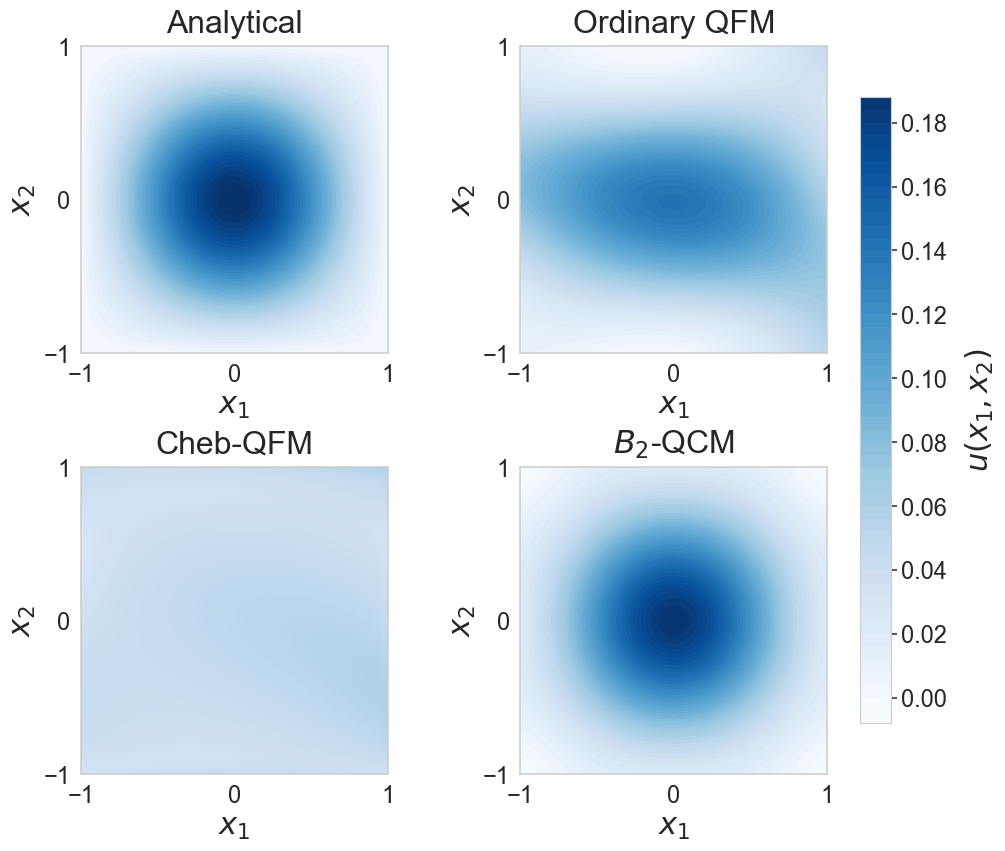

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_solution_comparison.png


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(10.4, 8.4), constrained_layout=True)
panels = [("Analytical", target_grid)] + list(predictions.items())

vmin = min(np.min(panel) for _, panel in panels)
vmax = max(np.max(panel) for _, panel in panels)

for ax, (title, values) in zip(axes.ravel(), panels):
    image = ax.contourf(
        grid_x1,
        grid_x2,
        values,
        levels=56,
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=23, pad=10)
    ax.set_xlabel("$x_1$", fontsize=22, labelpad=4)
    ax.set_ylabel("$x_2$", fontsize=22, labelpad=4)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis="both", labelsize=17, width=1.1, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

colorbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.86, pad=0.03)
colorbar.set_label("$u(x_1,x_2)$", fontsize=22, labelpad=12)
colorbar.ax.tick_params(labelsize=17, width=1.1, length=4)
solution_path = FIGURE_DIR / "qpinn_b2_autograd_solution_comparison.png"
fig.savefig(solution_path, dpi=240, bbox_inches="tight")
show_or_close_current_figure()
print(f"saved {solution_path}")

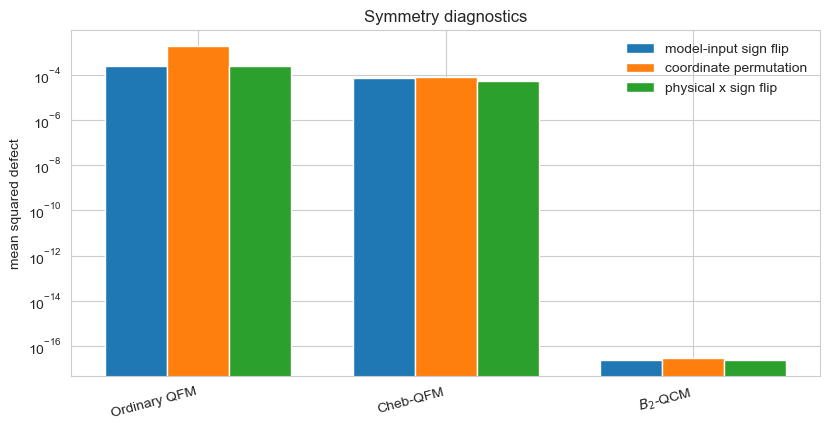

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_symmetry_metrics.png


In [100]:
labels = list(symmetry.keys())
model_sign_values = [symmetry[name]["model_input_sign_flip_mse"] for name in labels]
perm_values = [symmetry[name]["permutation_mse"] for name in labels]
physical_sign_values = [symmetry[name]["physical_evenness_mse"] for name in labels]

xpos = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8.4, 4.4))
plt.bar(xpos - width, model_sign_values, width, label="model-input sign flip")
plt.bar(xpos, perm_values, width, label="coordinate permutation")
plt.bar(xpos + width, physical_sign_values, width, label="physical x sign flip")
plt.yscale("log")
plt.xticks(xpos, labels, rotation=15, ha="right")
plt.ylabel("mean squared defect")
plt.title("Symmetry diagnostics")
plt.legend(frameon=False)
plt.tight_layout()
symmetry_path = FIGURE_DIR / "qpinn_b2_autograd_symmetry_metrics.png"
plt.savefig(symmetry_path, dpi=220)
show_or_close_current_figure()
print(f"saved {symmetry_path}")

## Interpretation

This notebook compares the Ordinary QFM, the Kyriienko-style Chebyshev feature map $f_\theta(\arccos x)$, and the exact $B_2$-symmetrized model $(A_{B_2}f_\theta)(x)$.

The Cheb-QFM baseline is intentionally imperfect: it uses the standard substitution $x\mapsto\arccos x$ but does not apply the sign-flip average that removes the non-polynomial terms discussed in the manuscript.  The $B_2$-QCM here uses the exact average over sign flips and coordinate permutations of the physical PDE input $x$.  This keeps the comparison focused: Cheb-QFM tests the conventional Chebyshev encoding baseline, while $B_2$-QCM tests the average-operator symmetry prior.

The training-loss plot reports the geometric mean loss over `N_RUNS` independent runs and shades one geometric standard deviation, computed as $\exp(\mathbb{E}[\log L] \pm \mathrm{std}[\log L])$.  This log-space summary is appropriate for losses spanning orders of magnitude and avoids artificial clipping from arithmetic mean-minus-standard-deviation bands.  The solution-comparison titles report each representative model's relative $L^2$ error and prediction range; this makes it explicit whether a panel is actually collapsed near zero or only appears visually compressed by the shared color scale.

The symmetry plot reports three diagnostics.  The model-input sign-flip defect checks the sign-flip action used by each model after its input map.  The coordinate-permutation defect checks exchange symmetry.  The physical $x$ sign-flip defect checks evenness in the original PDE coordinate.